# Handwriting Recognition -- Improved Training
**Model:** 3-block CNN with BatchNorm | **Dataset:** EMNIST byclass (62 classes)  
**Features:** Checkpoint resume - LR scheduling - tqdm progress - training curves

In [43]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import string
import os
from tqdm.auto import tqdm

# -- Config --------------------------------------------------------------------
CHECKPOINT_DIR  = './checkpoints'
NUM_CLASSES     = 62
BATCH_SIZE      = 256      # larger batch -- RTX 5070 Ti has 15.9 GB VRAM
EPOCHS          = 20
LR              = 0.001

os.makedirs(CHECKPOINT_DIR, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device : {device}')
if device.type == 'cuda':
    print(f'GPU          : {torch.cuda.get_device_name(0)}')
    print(f'VRAM         : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

# Character map: digits -> uppercase -> lowercase
classes = list(string.digits + string.ascii_uppercase + string.ascii_lowercase)
print(f'Classes      : {len(classes)}')

Using device : cuda
GPU          : NVIDIA GeForce RTX 5070 Ti
VRAM         : 17.1 GB
Classes      : 62


In [44]:
# Transforms
# EMNIST byclass images arrive transposed+mirrored: fix with rot90(k=3)+flip
_emnist_fix = [
    transforms.Lambda(lambda x: torch.rot90(x, k=3, dims=[1, 2])),
    transforms.Lambda(lambda x: torch.flip(x, dims=[2])),
    transforms.Normalize((0.1307,), (0.3081,))
]

# ElasticTransform removed -- it runs on CPU and stalls the GPU (num_workers=0).
# shear=5 added to RandomAffine to partially cover the variance.
train_transform = transforms.Compose([
    transforms.RandomRotation(15),
    transforms.RandomAffine(0, translate=(0.1, 0.1), shear=5),
    transforms.ToTensor(),
    *_emnist_fix,
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.15)),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    *_emnist_fix
])

train_dataset = torchvision.datasets.EMNIST(
    root="./data", split="byclass", train=True,
    download=True, transform=train_transform
)
test_dataset = torchvision.datasets.EMNIST(
    root="./data", split="byclass", train=False,
    download=True, transform=test_transform
)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE,
    shuffle=True, num_workers=0, pin_memory=True
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE,
    shuffle=False, num_workers=0, pin_memory=True
)

print(f"Train samples : {len(train_dataset):,}")
print(f"Test  samples : {len(test_dataset):,}")
print(f"Train batches : {len(train_loader):,}")

Train samples : 697,932
Test  samples : 116,323
Train batches : 2,727


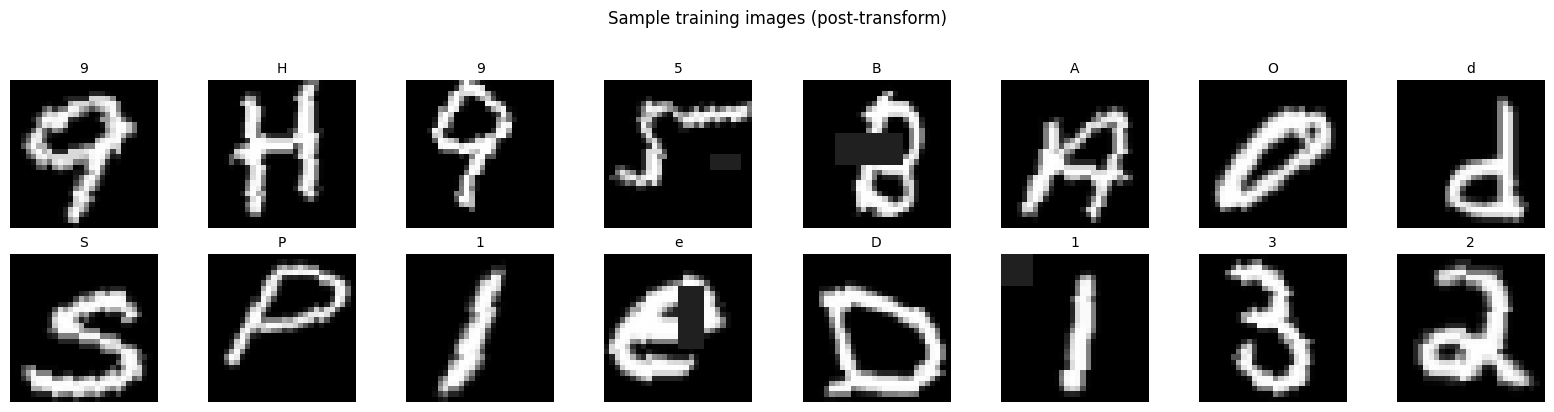

In [45]:
# -- Quick sanity-check: visualise 16 samples ---------------------------------
imgs, lbls = next(iter(train_loader))
plt.figure(figsize=(16, 4))
for i in range(16):
    plt.subplot(2, 8, i + 1)
    plt.imshow(imgs[i].squeeze().numpy(), cmap='gray')
    plt.title(classes[lbls[i].item()], fontsize=10)
    plt.axis('off')
plt.suptitle('Sample training images (post-transform)', y=1.02)
plt.tight_layout()
plt.show()

In [46]:
# ResNet-style model
# Each ResidualBlock = 2 convs with a skip connection.
# If dimensions change (stride>1 or channels differ), the shortcut projects
# with a 1x1 conv so the addition always works.

class ResidualBlock(nn.Module):
    def __init__(self, in_ch: int, out_ch: int, stride: int = 1):
        super().__init__()
        self.body = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
        )
        # Skip connection: identity if same shape, else 1x1 conv to match
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch),
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return F.relu(self.body(x) + self.shortcut(x))


class HandwritingResNet(nn.Module):
    def __init__(self, num_classes: int = 62):
        super().__init__()
        # Stem: 1->32, stays 28x28
        self.stem = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
        )
        # Layer 1: 32->64, 28x28 -> 14x14
        self.layer1 = nn.Sequential(
            ResidualBlock(32, 64, stride=2),
            ResidualBlock(64, 64),
        )
        # Layer 2: 64->128, 14x14 -> 7x7
        self.layer2 = nn.Sequential(
            ResidualBlock(64, 128, stride=2),
            ResidualBlock(128, 128),
        )
        # Layer 3: 128->256, 7x7 -> 4x4
        self.layer3 = nn.Sequential(
            ResidualBlock(128, 256, stride=2),
            ResidualBlock(256, 256),
        )
        # Global average pool -> 256-dim vector
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(256, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)


model = HandwritingResNet(NUM_CLASSES).to(device)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {total_params:,}")
print(model)


Trainable parameters: 2,773,278
HandwritingResNet(
  (stem): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (layer1): Sequential(
    (0): ResidualBlock(
      (body): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (shortcut): Sequential(
        (0): Conv2d(32, 64, kernel_size=(1, 1), stride=(2, 2), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (1): ResidualBlock(
  

In [47]:
# Optimizer, loss, scheduler, and checkpoint resume

targets = torch.tensor(train_dataset.targets)
class_counts = torch.bincount(targets, minlength=NUM_CLASSES).float()
class_weights = 1.0 / class_counts.clamp(min=1)
class_weights = (class_weights / class_weights.sum() * NUM_CLASSES).to(device)
print("Class weight range:", round(class_weights.min().item(), 4), "->", round(class_weights.max().item(), 4))

criterion  = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
optimizer  = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler  = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

# AMP GradScaler: keeps FP16 numerically stable by scaling gradients
scaler = torch.cuda.amp.GradScaler(enabled=device.type == "cuda")

BEST_CKPT = os.path.join(CHECKPOINT_DIR, "best_model.pth")
LAST_CKPT = os.path.join(CHECKPOINT_DIR, "last_checkpoint.pth")

start_epoch     = 0
best_acc        = 0.0
train_losses    = []
test_accuracies = []

if os.path.exists(LAST_CKPT):
    print(f"Resuming from: {LAST_CKPT}")
    ckpt = torch.load(LAST_CKPT, map_location=device)
    model.load_state_dict(ckpt["model_state"])
    optimizer.load_state_dict(ckpt["optimizer_state"])
    scheduler.load_state_dict(ckpt["scheduler_state"])
    if "scaler_state" in ckpt:
        scaler.load_state_dict(ckpt["scaler_state"])
    start_epoch     = ckpt["epoch"] + 1
    best_acc        = ckpt.get("best_acc", 0.0)
    train_losses    = ckpt.get("train_losses", [])
    test_accuracies = ckpt.get("test_accuracies", [])
    print(f"  -> Resuming at epoch {start_epoch} | best acc: {best_acc:.2f}%")
else:
    print("No checkpoint found -- starting fresh.")

Class weight range: 0.1265 -> 2.5599
No checkpoint found -- starting fresh.


C:\Users\Pc\AppData\Local\Temp\ipykernel_20528\4113876619.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  targets = torch.tensor(train_dataset.targets)
C:\Users\Pc\AppData\Local\Temp\ipykernel_20528\4113876619.py:14: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=device.type == "cuda")


In [48]:
# Training loop with AMP (Automatic Mixed Precision)

def evaluate(model, loader):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for imgs, lbls in loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            with torch.autocast(device_type=device.type, dtype=torch.float16):
                _, preds = torch.max(model(imgs), 1)
            total   += lbls.size(0)
            correct += (preds == lbls).sum().item()
    return 100.0 * correct / total


for epoch in range(start_epoch, EPOCHS):
    model.train()
    running_loss = 0.0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1:02d}/{EPOCHS}", leave=True)
    for imgs, lbls in pbar:
        imgs, lbls = imgs.to(device), lbls.to(device)
        optimizer.zero_grad()

        with torch.autocast(device_type=device.type, dtype=torch.float16):
            loss = criterion(model(imgs), lbls)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    avg_loss = running_loss / len(train_loader)
    test_acc = evaluate(model, test_loader)
    scheduler.step()

    train_losses.append(avg_loss)
    test_accuracies.append(test_acc)

    current_lr = optimizer.param_groups[0]["lr"]
    print(f"  Loss: {avg_loss:.4f}  |  Test Acc: {test_acc:.2f}%  |  LR: {current_lr:.6f}")

    torch.save({
        "epoch"           : epoch,
        "model_state"     : model.state_dict(),
        "optimizer_state" : optimizer.state_dict(),
        "scheduler_state" : scheduler.state_dict(),
        "scaler_state"    : scaler.state_dict(),
        "best_acc"        : best_acc,
        "train_losses"    : train_losses,
        "test_accuracies" : test_accuracies,
    }, LAST_CKPT)

    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(model.state_dict(), BEST_CKPT)
        print(f"  New best model saved -> {best_acc:.2f}%")

print(f"Training complete. Best test accuracy: {best_acc:.2f}%")

Epoch 01/20: 100%|██████████| 2727/2727 [02:01<00:00, 22.36it/s, loss=2.3387]


  Loss: 2.1500  |  Test Acc: 79.80%  |  LR: 0.000994
  New best model saved -> 79.80%


Epoch 02/20: 100%|██████████| 2727/2727 [02:01<00:00, 22.43it/s, loss=1.8384]


  Loss: 1.9642  |  Test Acc: 81.94%  |  LR: 0.000976
  New best model saved -> 81.94%


Epoch 03/20: 100%|██████████| 2727/2727 [02:04<00:00, 21.89it/s, loss=2.2233]


...

  Loss: 1.7938  |  Test Acc: 83.41%  |  LR: 0.000025


Epoch 19/20: 100%|██████████| 2727/2727 [02:06<00:00, 21.63it/s, loss=1.5483]


  Loss: 1.7909  |  Test Acc: 83.97%  |  LR: 0.000007


Epoch 20/20: 100%|██████████| 2727/2727 [02:04<00:00, 21.95it/s, loss=1.9593]


  Loss: 1.7908  |  Test Acc: 83.91%  |  LR: 0.000001
Training complete. Best test accuracy: 84.74%


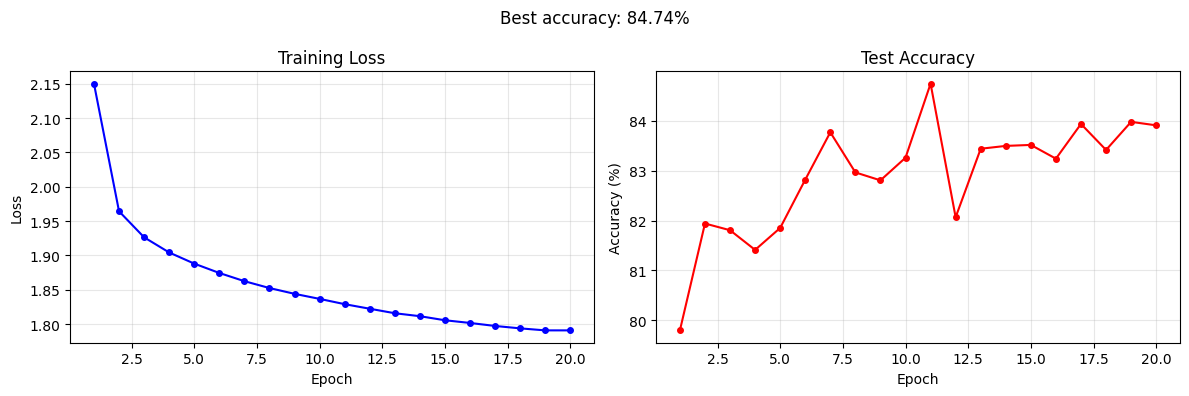

In [49]:
# -- Training Curves -----------------------------------------------------------
epochs_range = range(1, len(train_losses) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs_range, train_losses, 'b-o', markersize=4)
ax1.set_title('Training Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range, test_accuracies, 'r-o', markersize=4)
ax2.set_title('Test Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.grid(True, alpha=0.3)

plt.suptitle(f'Best accuracy: {max(test_accuracies):.2f}%', fontsize=12)
plt.tight_layout()
plt.show()

In [50]:
# -- Load best model for evaluation -------------------------------------------
model.load_state_dict(torch.load(BEST_CKPT, map_location=device))
model.eval()
print(f'Loaded best model. Evaluating...')

# Per-class accuracy
class_correct = [0] * NUM_CLASSES
class_total   = [0] * NUM_CLASSES

with torch.no_grad():
    for imgs, lbls in tqdm(test_loader, desc='Evaluating'):
        imgs, lbls = imgs.to(device), lbls.to(device)
        _, preds = torch.max(model(imgs), 1)
        for lbl, pred in zip(lbls, preds):
            class_correct[lbl] += int(pred == lbl)
            class_total[lbl]   += 1

overall = 100 * sum(class_correct) / sum(class_total)
print(f'Overall test accuracy: {overall:.2f}%\n')

# Show bottom-10 hardest classes
per_class = [(classes[i], 100 * class_correct[i] / class_total[i]) for i in range(NUM_CLASSES) if class_total[i] > 0]
per_class.sort(key=lambda x: x[1])
print('10 hardest classes:')
for ch, acc in per_class[:10]:
    print(f'  {ch!r:4s}  {acc:.1f}%')

Loaded best model. Evaluating...


Evaluating: 100%|██████████| 455/455 [00:20<00:00, 22.53it/s]

Overall test accuracy: 84.74%

10 hardest classes:
  's'   35.7%
  'l'   35.8%
  'o'   43.3%
  'O'   47.0%
  'm'   47.4%
  'V'   50.0%
  'c'   54.9%
  'i'   56.2%
  'I'   58.5%
  'x'   61.7%


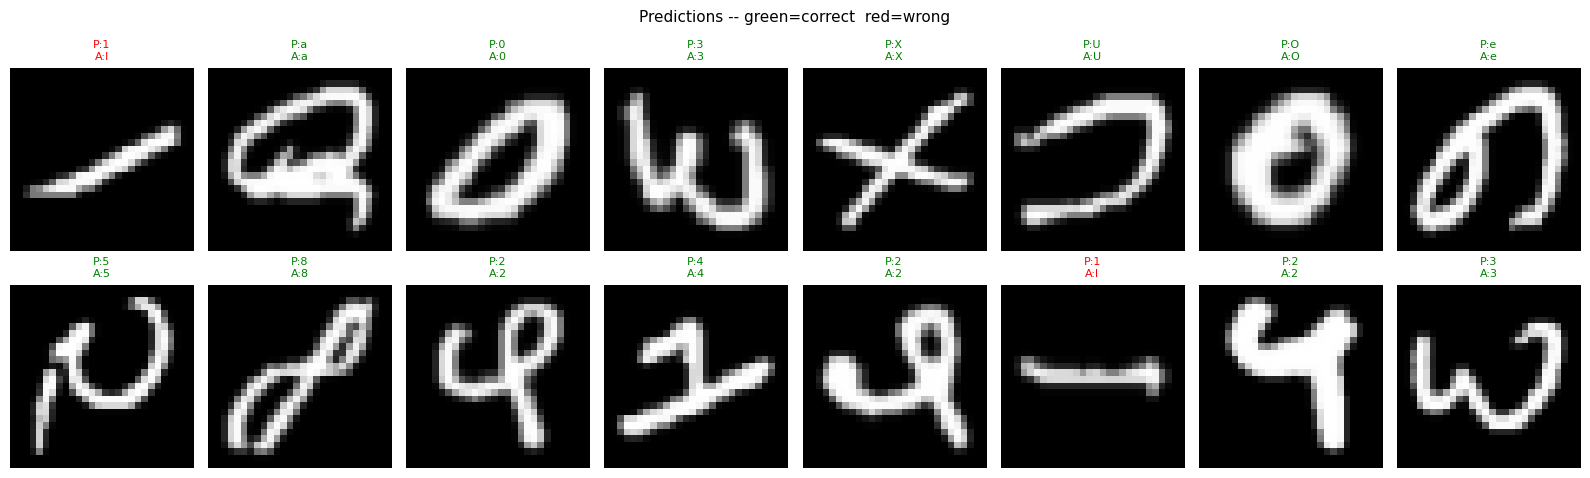

In [51]:
# -- Visualise predictions (green = correct, red = wrong) ---------------------
imgs, lbls = next(iter(test_loader))
imgs, lbls = imgs.to(device), lbls.to(device)
with torch.no_grad():
    _, preds = torch.max(model(imgs), 1)

plt.figure(figsize=(16, 5))
for i in range(16):
    plt.subplot(2, 8, i + 1)
    img = imgs[i].cpu().squeeze().numpy()
    plt.imshow(np.transpose(img), cmap='gray')
    correct = preds[i] == lbls[i]
    color   = 'green' if correct else 'red'
    plt.title(
        f"P:{classes[preds[i].item()]}\nA:{classes[lbls[i].item()]}",
        color=color, fontsize=8
    )
    plt.axis('off')

plt.suptitle('Predictions -- green=correct  red=wrong', fontsize=11)
plt.tight_layout()
plt.show()